# DDPM on MNIST
Here, we want to implement and train a simple diffusion model on the MNIST data set, which learns to generate images of handwritten digits.

### Imports and loading the data

In [2]:
!pip install torch_lr_finder

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# cell generated with Claude
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_set = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_set)}, Test samples: {len(test_set)}")

Training samples: 60000, Test samples: 10000


In [5]:
train_set[0][0].shape

torch.Size([1, 28, 28])

In [6]:
train_set[0][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [7]:
train_set[0][1]

5

train and test here are Dataset objects.

They are a list of tuples, each tuple with a 1x28x28 tensor first and an integer number as the second element. the tensors are grayscale values for each pixel, between 0 and 1.

In [8]:
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader

batch_size = 64

## Part 1: Building the initial unet
We will now build initially an unconditioned unet, which does not take in the text-embedding. Our architecture uses 3x3 pooling with padding = 1 and a 2x2 MaxPool and ReLU activation. for the upsampling, we use 3x3 convolutions with padding 1 and 2x2 upsampling (interpolation) steps. the upsampling steps do not have learnable parameters

1x28x28 -> 8x28x28
-> 8x14x14 -> 16x14x14
-> 16x7x7 -> 32x7x7
-> 32x14x14 -> 16x14x14
-> 16x28x28 -> 1x28x28

This is adapted from the original paper introducing the unet (Ronneberger et al).

in the first step, we don't put in skip connections, etc (although if I understand it correctly, the skip connections are very much a defining feature of the unet, and what i build here is more of a VAE) we will look at all this stuff later. also we will ignore time embedding for now.

In [9]:
from typing import List

class UNet(nn.Module):

    def __init__(self, channels: List[int] = [8, 16, 32,16],
                 kernel_size=3, pool_size=2, padding=1):
        super().__init__()
        
        # prepend and append 1 for input/output channels
        full_channels = [1] + channels + [1]
        mid = len(channels) // 2  # bottleneck index: separates the encoder (downsampling) part from the decoder (upsampling part)
        
        self.convs = nn.ModuleList([
            nn.Conv2d(full_channels[i], full_channels[i+1], kernel_size, padding=padding)
            for i in range(len(full_channels) - 1)
        ])
        self.mid = mid
        self.pool = nn.MaxPool2d(pool_size)
        self.upsample = nn.Upsample(scale_factor=pool_size, #mode='bilinear', align_corners=False
                                    )
        self.activation_fn = F.relu

    def forward(self, x): # this can probably be done more elegantly, but for now we run with this
        last = len(self.convs) - 1
        for i, conv in enumerate(self.convs):
            is_last = (i == last)
            if i < self.mid:
                x = self.activation_fn(conv(x))
                x = self.pool(x)
            elif i > self.mid:
                x = self.upsample(x)
                x = conv(x) if is_last else self.activation_fn(conv(x))
            else:
                x = self.activation_fn(conv(x))
        return x
    
        

now, we need a noise generator, to generate the noisy training data. this noise generator will take in an image and a time parameter t and will give back a noisy image. 

We will use the variance schedule from the original Ho et al. (2020) paper, where beta linearly increases from beta_1 = 1e-4, beta_T = 0.02

In [ ]:
T = 1000

def get_schedule(T):
    betas = torch.linspace(1e-4, 0.02, T)
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars

betas,alphas,alpha_bars = get_schedule(T)

def get_beta(t):
    b = betas[t]
    if isinstance(t, (torch.Tensor, np.ndarray)):
        b = b.reshape(-1, 1, 1, 1)
    return b

def get_alpha(t):
    a = alphas[t]
    if isinstance(t, (torch.Tensor, np.ndarray)):
        a = a.reshape(-1, 1, 1, 1)
    return a

def get_alpha_bar(t):
    ab = alpha_bars[t]
    if isinstance(t, (torch.Tensor, np.ndarray)):
        ab = ab.reshape(-1, 1, 1, 1)
    return ab

In [11]:
def add_noise(x, t):
    """
    Written by Claude
    x: (B, 1, H, W) image tensor, values in [0, 1]
    t: (B,) integer timestep tensor
    T: total number of timesteps
    """
    noise = torch.randn_like(x)
    alpha = get_alpha(t)  # noise level: 1 at t=0, 0 at t=T. view does the proper reshaping(t_dim,1,1,1) to broadcast the alpha well onto the image
    return alpha * x + (1 - alpha) * noise, noise

or we rather turn this into a module actually, that is cleaner

In [ ]:
class NoiseScheduler(nn.Module):
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        betas = torch.linspace(beta_start, beta_end, T)
        alphas = 1 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        
        # register as buffers — not parameters, but move with .to(device)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)
        self.T = T

    def _reshape(self, x, t):
        return x.reshape(-1, 1, 1, 1) if isinstance(t, (torch.Tensor, np.ndarray)) else x

    def beta(self, t):      return self._reshape(self.betas[t], t)
    def alpha(self, t):     return self._reshape(self.alphas[t], t)
    def alpha_bar(self, t): return self._reshape(self.alpha_bars[t], t)

    def add_noise(self, x, t):
        noise = torch.randn_like(x)
        ab = self.alpha_bar(t)
        return torch.sqrt(ab) * x + torch.sqrt(1 - ab) * noise, noise
    
scheduler = NoiseScheduler(T=T).to(device)

now, we can train: the training data is generated on the fly in the loop: for each batch, we draw t's, and generate a noisy image based on this t. then, we train the model on it.

### finding the learning rate
first however, we try to find the learning rate. we do this with the very convenient torch_lr_finder. for that, however, we need to build a custom dataset for the noisy images, which generates a noisy image when getitem is called.

In [12]:
from torch_lr_finder import LRFinder

/usr/local/lib/python3.12/dist-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [52]:
# cell written by Claude
class NoisyMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset, scheduler):
        self.dataset = dataset
        self.scheduler = scheduler
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        x, _ = self.dataset[idx] # the second entry (the number) is being ignored
        t = torch.randint(0, self.scheduler.T, (1,))
        x_noisy, noise = self.scheduler.add_noise(x.unsqueeze(0), t)
        return x_noisy.squeeze(0), noise.squeeze(0)

noisy_train = NoisyMNIST(train_set,scheduler)
noisy_loader = DataLoader(noisy_train, batch_size=64, shuffle=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 4.43E-01


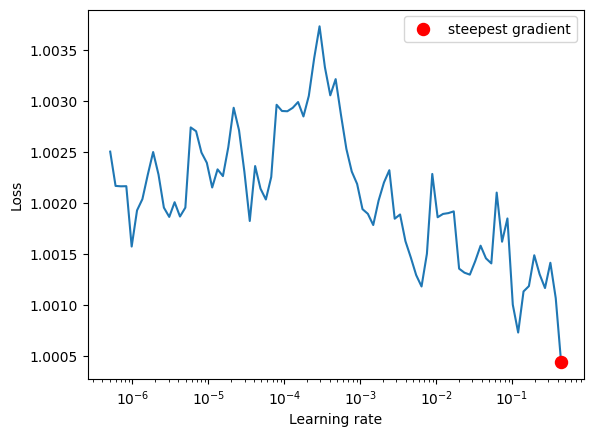

(<Axes: xlabel='Learning rate', ylabel='Loss'>, 0.4430621457583881)

In [14]:
model = UNet().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-7)

lr_finder = LRFinder(model, optimizer, F.mse_loss)
lr_finder.range_test(noisy_loader, end_lr=1, num_iter=100)
lr_finder.plot()

based on this, we will start with 1e-2 as a learning rate.

### filtering the datasets
to make things faster, we will only train the model for now to generate zeros.


In [53]:
# cell generated by Claude
from torch.utils.data import Subset

def zeros_only(dataset):
    indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
    return Subset(dataset, indices)

train_zeros = zeros_only(train_set)
test_zeros  = zeros_only(test_set)

noisy_train_zeros = NoisyMNIST(train_zeros,scheduler)
noisy_test_zeros  = NoisyMNIST(test_zeros,scheduler)

train_loader = DataLoader(noisy_train_zeros, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(noisy_test_zeros,  batch_size=batch_size, shuffle=False)

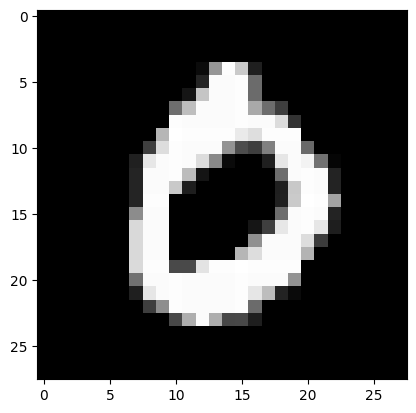

In [16]:
plt.imshow(test_zeros[0][0].squeeze(),cmap="gray")

this looks the way it should

### training the model

In [17]:
model = UNet().to(device)
lr = 1e-2


we can define a function for the training. 

for speeding up, i use autocast and GradScaler, which, where it is possible, scales numbers to half precision (16 bit), which on gpus allows for significant improvements in speed. GradScaler and autocast deal with issues that can arise here when we just use .half().

In [18]:
def train(model, train_loader, test_loader, epochs=5, lr=1e-2, plot_loss=True):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda')
    loss_fn = nn.MSELoss()
    train_losses, test_losses = [], []

    for epoch in tqdm(range(epochs),desc='Epochs'):
        model.train()
        epoch_train_loss = 0
        for x_noisy, noise in tqdm(train_loader,leave=False,desc='train'):
            x_noisy, noise = x_noisy.to(device), noise.to(device)
            with torch.amp.autocast('cuda'):
                noise_pred = model(x_noisy)
                loss = loss_fn(noise_pred, noise)
            epoch_train_loss += loss.item()
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for x_noisy, noise in tqdm(test_loader,leave=False,desc='test'):
                x_noisy, noise = x_noisy.to(device), noise.to(device)
                with torch.amp.autocast('cuda'):
                    noise_pred = model(x_noisy)
                    epoch_test_loss += loss_fn(noise_pred, noise).item()
        test_losses.append(epoch_test_loss / len(test_loader))

        print(f"Epoch {epoch} | train loss: {train_losses[-1]:.4f} | test loss: {test_losses[-1]:.4f}")

    if plot_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train')
        plt.plot(test_losses, label='Test')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curve')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return train_losses, test_losses

now, the magic moment: we train

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 0 | train loss: 0.9994 | test loss: 1.0021


train:   0%|          | 0/93 [00:00<?, ?it/s]

...

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.9995 | test loss: 1.0021


train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.9998 | test loss: 1.0001


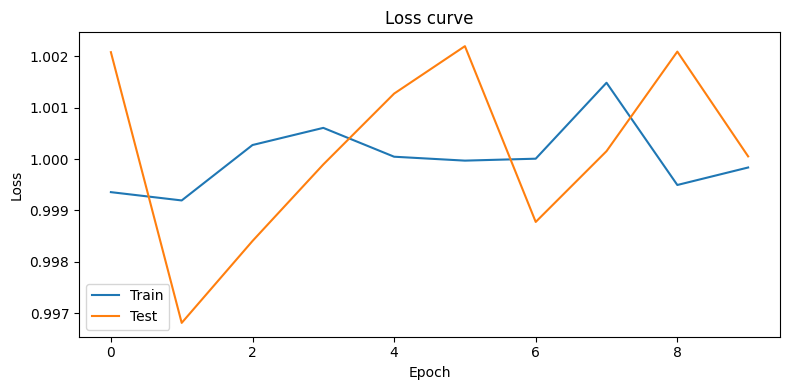

In [19]:
train(model,train_loader,test_loader,epochs=10);

the autocast,GradScaler stuff leads to an approximate 2.5x-3x speed up

okay, this didn't work, but still, we have a running model. There are several possible reasons:

batch_size, learning_rate, skip_connections, and t embedding

## Part 2: Getting it to work

Now, we start testing: halving the batch_size

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 0 | train loss: 1.0010 | test loss: 0.9993


train:   0%|          | 0/186 [00:00<?, ?it/s]

...

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.9989 | test loss: 0.9990


train:   0%|          | 0/186 [00:00<?, ?it/s]

test:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.9992 | test loss: 0.9999


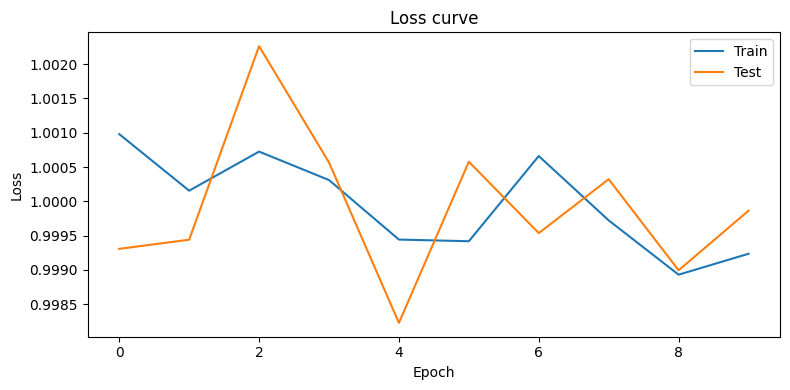

In [20]:
batch_size = 32


train_loader = DataLoader(noisy_train_zeros, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(noisy_test_zeros,  batch_size=batch_size, shuffle=False)

train(model,train_loader,test_loader,epochs=10);

This doesn't really do anything, which was expected. What about learning rate: 1e-2 could be way too high. When looking at the learning_rate finder again at a later run, we see that 1e-2 is actually not a good learning rate in that case. we should've been more conservative probably


  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 2.01E-02


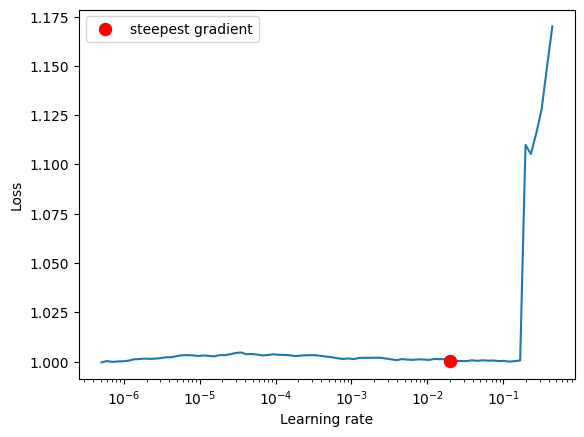

(<Axes: xlabel='Learning rate', ylabel='Loss'>, 0.020092330025650466)

In [21]:
model = UNet().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-7)

lr_finder = LRFinder(model, optimizer, F.mse_loss)
lr_finder.range_test(noisy_loader, end_lr=1, num_iter=100)
lr_finder.plot()

running the learning rate finder several times, we find that the plot varies wildly on different runs. 2e-3 seems to be an estimate which works well most of the time (though even then not consistently)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 0 | train loss: 1.2236 | test loss: 1.0200


train:   0%|          | 0/93 [00:00<?, ?it/s]

...

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 8 | train loss: 0.9990 | test loss: 1.0035


train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.9999 | test loss: 0.9990


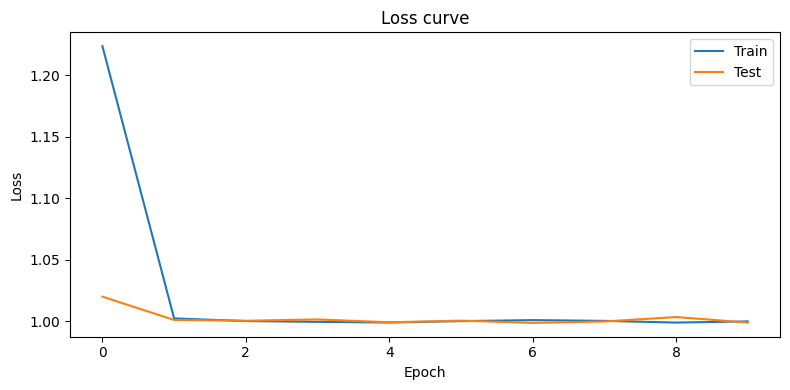

In [22]:
batch_size = 64
lr = 2e-3

train_loader = DataLoader(noisy_train_zeros, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(noisy_test_zeros,  batch_size=batch_size, shuffle=False)

train(model,train_loader,test_loader,epochs=10);

this doesn't really help either. Let's take out the bigger guns then: we include skip connections between the layers, which allows gradients to trickle back, and we do the t embedding. With that, we are building an actual unet

### Including Skip connections

What we do now is to edit the network architecture: we include connections between the layers of same size: we connect the first 28x28 conv output with the last 28x28 conv input (we just take the earlier output as new input channels for the later ones), same for 14x14 layers.


In [23]:
# editing done with Claude
class UNet(nn.Module):

    def __init__(self, channels: List[int] = [8, 16, 32, 16],
                 kernel_size=3, pool_size=2, padding=1):
        super().__init__()
        
        full_channels = [1] + channels + [1]
        self.mid = len(full_channels) // 2

        self.encoder_convs = nn.ModuleList([
            nn.Conv2d(full_channels[i], full_channels[i+1], kernel_size, padding=padding)
            for i in range(self.mid)
        ])
        
        # decoder channels are doubled because of skip concatenation
        self.decoder_convs = nn.ModuleList([
            nn.Conv2d(
                full_channels[self.mid + i] + full_channels[self.mid - i -1],  # upsampled + skip
                full_channels[self.mid + i + 1],
                kernel_size, padding=padding
            )
            for i in range(len(full_channels) - self.mid-1)
        ])

        self.pool = nn.MaxPool2d(pool_size)
        self.upsample = nn.Upsample(scale_factor=pool_size)
        self.activation_fn = F.relu

    def forward(self, x):
        # encoder — save outputs for skip connections
        skips = []
        for i, conv in enumerate(self.encoder_convs):
            x = self.activation_fn(conv(x))
            if i < len(self.encoder_convs) - 1:  # don't pool after bottleneck
                skips.append(x)
                x = self.pool(x)

        # decoder — pop skips in reverse order
        for i, conv in enumerate(self.decoder_convs):
            x = self.upsample(x)
            x = torch.cat([x, skips.pop()], dim=1)  # concat along channel dim
            is_last = (i == len(self.decoder_convs) - 1)
            x = conv(x) if is_last else self.activation_fn(conv(x))

        return x

let's check what the optimal learning rate for this architecture might be

In [24]:
model = UNet().to(device)

len(model.decoder_convs)

2

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.67E-01


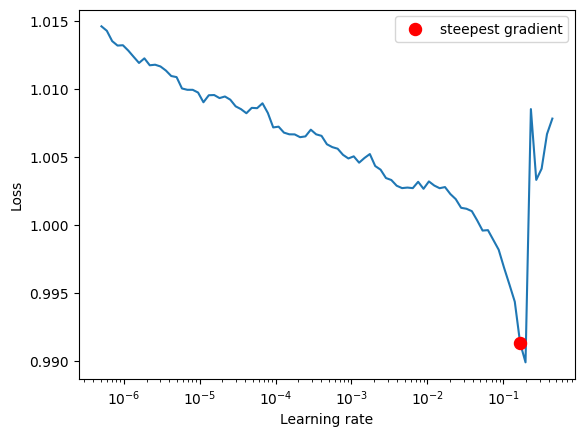

(<Axes: xlabel='Learning rate', ylabel='Loss'>, 0.16681005372000574)

In [25]:
model = UNet().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-7)

lr_finder = LRFinder(model, optimizer, F.mse_loss)
lr_finder.range_test(noisy_loader, end_lr=1, num_iter=100)
lr_finder.plot()

this for the first time looks like a curve i would expect. the curve is also much more consistent. We set the learning rate to 1.5e-2

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 0 | train loss: 1.0051 | test loss: 0.9985


train:   0%|          | 0/93 [00:00<?, ?it/s]

...

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 8 | train loss: 1.0006 | test loss: 0.9977


train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9 | train loss: 0.9989 | test loss: 1.0000


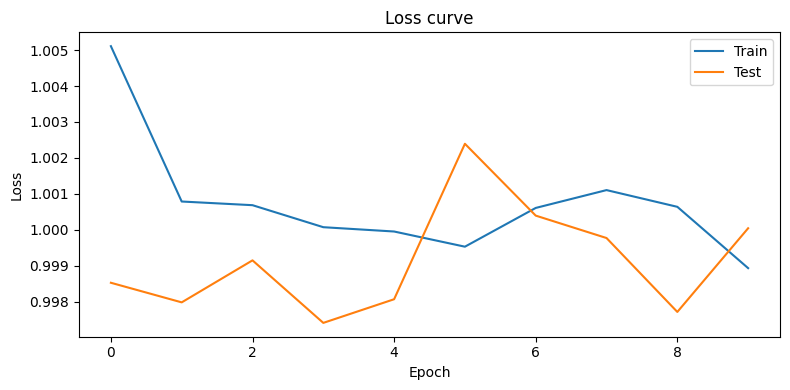

In [26]:
lr = 1.5e-2

train_loader = DataLoader(noisy_train_zeros, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(noisy_test_zeros,  batch_size=batch_size, shuffle=False)

train(model,train_loader,test_loader,epochs=10,lr=lr);

This really seems to work well! The skip connections turn out to be essential to training the model correctly.

Before we do further additions to the model, let's train it a bit more. for that, we add early_stopping to the train function and let it run a bit. we also add a saving feature to the train function, so that we have the weights stored at the end of the training.

In [27]:
# edits done by Claude

def train(model, train_loader, test_loader, epochs=100, lr=1e-2, plot_loss=True,
          early_stopping_patience=5, save_path='model.pkl'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda')
    loss_fn = nn.MSELoss()
    train_losses, test_losses = [], []
    
    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in tqdm(range(epochs), desc='Epochs'):
        model.train()
        epoch_train_loss = 0
        for x_noisy, noise in tqdm(train_loader, leave=False, desc='train'):
            x_noisy, noise = x_noisy.to(device), noise.to(device)
            with torch.amp.autocast('cuda'):
                noise_pred = model(x_noisy)
                loss = loss_fn(noise_pred, noise)
            epoch_train_loss += loss.item()
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for x_noisy, noise in tqdm(test_loader, leave=False, desc='test'):
                x_noisy, noise = x_noisy.to(device), noise.to(device)
                with torch.amp.autocast('cuda'):
                    noise_pred = model(x_noisy)
                    epoch_test_loss += loss_fn(noise_pred, noise).item()
        test_losses.append(epoch_test_loss / len(test_loader))

        print(f"Epoch {epoch} | train loss: {train_losses[-1]:.4f} | test loss: {test_losses[-1]:.4f}")

        # early stopping
        if test_losses[-1] < best_test_loss:
            best_test_loss = test_losses[-1]
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best model
    model.load_state_dict(torch.load(save_path))

    if plot_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train')
        plt.plot(test_losses, label='Test')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curve')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return train_losses, test_losses

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 0 | train loss: 1.8464 | test loss: 0.9950


train:   0%|          | 0/93 [00:00<?, ?it/s]

...

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 91 | train loss: 0.4278 | test loss: 0.4256


train:   0%|          | 0/93 [00:00<?, ?it/s]

test:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 92 | train loss: 0.4247 | test loss: 0.4173
Early stopping at epoch 92


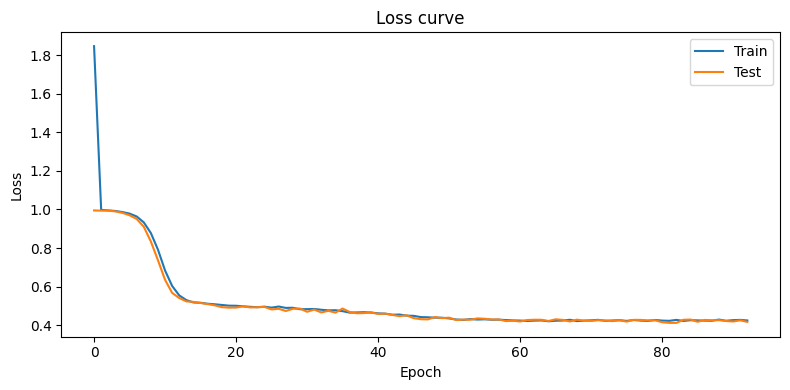

In [ ]:
model = UNet().to(device)
lr = 1.5e-2

train(model,train_loader,test_loader,
      epochs=200,lr=lr,early_stopping_patience=10,
      save_path='model_unet_no_t_emb.pkl');

Our test loss is still very high. but we will continue for now to finish the pipeline

## Part 3: Finishing the Pipeline (i.e. generating an image)

We trained the unet, now we implement the diffusion process: we build a noise generator, put it into the unet, let it generate the noise pattern and subtract that. So far, we don't have t embedding, so we have to see how we will adapt the process so as to exclude t

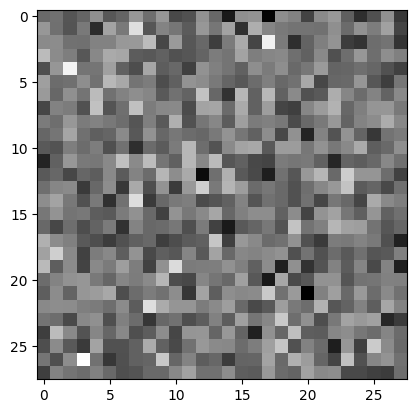

In [34]:
example_image = train_zeros[0][0].squeeze()

def noisy_image(n=1):
    """generates a batch of n noisy images. Output shape: (nx28x28)"""
    return torch.randn((n,1,*example_image.shape))

plt.imshow(noisy_image().squeeze(),cmap="gray")
plt.show()

now, we go through the DDPM algorithm: 
1. we generate a random image
2. for t = T,...,1 we
3. sample z from a normal distribution, for t>1, else z=0,
4. deduct noise from the image, and readd noise z
5. return x(t=0)

In [57]:
scheduler = NoiseScheduler(T=50)


def generate_image(unet,n_images=1,return_intermediates=False):
    intermediates = []
    x = noisy_image(n_images).to(device)
    if return_intermediates:
        intermediates.append(x)
    for t in range(scheduler.T-1,0,-1):
        z = noisy_image(n_images).to(device) if t>1 else torch.zeros_like(x)
        alpha = scheduler.alpha(t)
        alpha_bar = scheduler.alpha_bar(t)
        sigma_t = torch.sqrt(scheduler.beta(t)) # sigma_t is here for this simple case set to sqrt(beta), like in the original ho et al paper

        noise_pred = unet(x)
        x = 1/torch.sqrt(alpha) * (x - (1-alpha)/torch.sqrt(1-alpha_bar)*noise_pred) + sigma_t*z

        #print(t, alpha_bar.item(), (1-alpha_bar).item())

        if return_intermediates:
            intermediates.append(x)
    

    if return_intermediates:
        return x,intermediates
    
    return x
    

In [36]:
def plot_image(image):
    plt.imshow(image.cpu().detach().squeeze(),cmap="gray")
    plt.colorbar()

now we test our new function for T=100

In [58]:
image,intermediates = generate_image(model,n_images=1,return_intermediates=True)


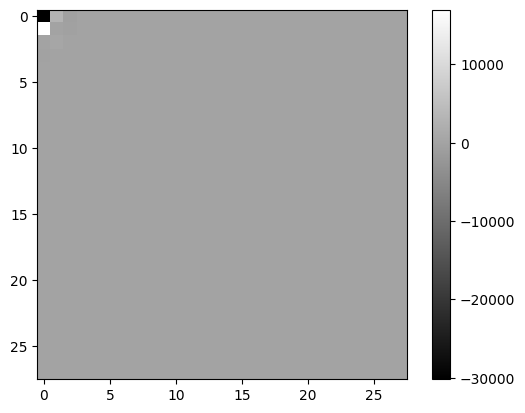

In [59]:
plot_image(intermediates[-1])

we have an explosion, which is probably due to our model still not being well trained. our errors are very high -> 0.41 is our mean test error.

steps: check input range, check why we have concentration in the corner.

add t embedding?

Steps:


time embedding

do proper noise schedule (with beta_t, alpha_t, etc), use cosine based variance schedule (nochol & dhariwal)

conditioning on input numbers

changing architecture?

put in dropout, batch_normalization, etc?